In [1]:
!pip install -q scikit-learn albumentations rasterio tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 82.5 MB/s eta 0:00:00


In [ ]:
import csv
import os
import pickle
import random
from pathlib import Path
from typing import List

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from skimage.transform import resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import torch
from torch.profiler import ProfilerActivity, profile, record_function
from tqdm import tqdm

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR   = '/kaggle/input/cloud-masking-dataset/content/train'
OUTPUT_DIR = '/kaggle/working'
MODEL_PATH = os.path.join(OUTPUT_DIR, 'cloud_mask_rf.pkl')
CSV_PATH   = os.path.join(OUTPUT_DIR, 'dice_scores_rf.csv')
LOGS_PATH  = os.path.join(OUTPUT_DIR, 'rf_profiler.txt')

CONFIG = {
    'img_size'        : 512,
    'resize_for_rf'   : 256,
    'n_estimators'    : 128,
    'max_depth'       : None,
    'train_pixels'    : 250_000,
    'pixels_per_class_per_img': 300,
    'rf_batch'        : 65_536,
    'val_split'       : 0.20,
    'device'          : torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

print(f'Using device  ➜  {CONFIG["device"]}')

Using device  ➜  cuda


In [4]:
DATASET_PATH   = Path(DATA_DIR)
IMAGES_DIR     = DATASET_PATH / 'data'
MASKS_DIR      = DATASET_PATH / 'masks'

image_paths = sorted(IMAGES_DIR.rglob("*.tif"))
mask_paths  = sorted(MASKS_DIR.rglob("*.tif"))

print(f'Total images: {len(image_paths)}  |  Total masks: {len(mask_paths)}')

Total images: 10573  |  Total masks: 10573


In [ ]:
def read_image(path):
    """
    Reads a four-band image from the specified path using rasterio and normalizes
    each band to the range [0, 1].

    Args:
        path (str): Path to the image file.

    Returns:
        np.ndarray: 3D float32 array with dimensions H*W*4, representing the four-band image.
    """
    with rasterio.open(path) as src:
        img = np.stack([src.read(i+1) for i in range(4)], axis=2).astype(np.float32)
    for c in range(4):
        m = img[...,c].max()
        if m>0: img[...,c] /= m
    return img

def read_mask(path):
    """
    Reads a binary mask from the specified path using rasterio. The mask is returned as a uint8
    array where cloud pixels are marked as 1 and clear pixels as 0.

    Args:
        path (str): Path to the mask file.

    Returns:
        np.ndarray: 2D uint8 binary mask array with dimensions H*W.
    """
    with rasterio.open(path) as src:
        m = src.read(1)
    return (m>0).astype(np.uint8)

def dice_coef(pred, gt, eps=1e-6):
    """
    Calculates the Dice coefficient between the predicted and ground truth binary masks.

    Args:
        pred (np.ndarray): Predicted binary mask.
        gt (np.ndarray): Ground truth binary mask.
        eps (float, optional): Smoothing factor to prevent division by zero. Defaults to 1e-6.

    Returns:
        float: Dice coefficient score ranging from 0 to 1, where 1 represents a perfect match.
    """
    inter = np.logical_and(pred, gt).sum()
    return (2*inter+eps)/(pred.sum()+gt.sum()+eps)

In [6]:
train_img, val_img, train_msk, val_msk = train_test_split(
    image_paths, mask_paths,
    test_size=CONFIG['val_split'],
    random_state=SEED, shuffle=True)

print(f'Train imgs: {len(train_img)} | Val imgs: {len(val_img)}')

Train imgs: 8458 | Val imgs: 2115


In [ ]:
def build_pixel_dataset(img_paths, msk_paths, max_pixels):
    """
    Builds a pixel-level dataset from image and mask paths, sampling pixels corresponding to cloud and clear regions.

    Args:
        img_paths (List[str]): List of image file paths.
        msk_paths (List[str]): List of mask file paths.
        max_pixels (int): Maximum number of pixels to sample for the dataset.

    Returns:
        tuple: (X, y), where X is a numpy array containing sampled image pixels, and y is the corresponding array of labels (1 for cloud, 0 for clear).
    """
    X, y = [], []
    per_class = CONFIG['pixels_per_class_per_img']
    bar = tqdm(zip(img_paths, msk_paths), total=len(img_paths), desc='Sampling pixels')
    for im_p, ms_p in bar:
        img = read_image(im_p)
        msk = read_mask(ms_p)
        
        cloud_idx = np.argwhere(msk==1)
        clear_idx = np.argwhere(msk==0)
        if len(cloud_idx):
            sel = cloud_idx[np.random.choice(len(cloud_idx),
                                             min(per_class, len(cloud_idx)),
                                             replace=False)]
            X.append(img[sel[:,0], sel[:,1]])
            y.extend([1]*len(sel))
        if len(clear_idx):
            sel = clear_idx[np.random.choice(len(clear_idx),
                                             min(per_class, len(clear_idx)),
                                             replace=False)]
            X.append(img[sel[:,0], sel[:,1]])
            y.extend([0]*len(sel))
        if len(y)>=max_pixels: break

    X = np.vstack(X)[:max_pixels]
    y = np.array(y)[:max_pixels]
    print(f'Pixel dataset ➜  {X.shape[0]} samples   clouds={y.sum()}  clear={len(y)-y.sum()}')
    return X, y

In [ ]:
# NOTE: Uncomment the following to train the model

# pixel_X, pixel_y = build_pixel_dataset(train_img, train_msk, CONFIG['train_pixels'])

# rf_clf = RandomForestClassifier(
#     n_estimators = CONFIG['n_estimators'],
#     max_depth    = CONFIG['max_depth'],
#     n_jobs       = -1,
#     random_state = SEED,
#     verbose      = 0
# )

# print('Fitting Random-Forest …')
# rf_clf.fit(pixel_X, pixel_y)

# with open(MODEL_PATH, 'wb') as f: pickle.dump(rf_clf, f)
# print(f'Model saved at: {MODEL_PATH}')

Sampling pixels:   6%|▌         | 492/8458 [00:36<09:50, 13.50it/s]


Pixel dataset ➜  250000 samples   clouds=138089  clear=111911
Fitting Random-Forest …
Model saved at: /kaggle/working/cloud_mask_rf.pkl


In [ ]:
def predict_mask(img, model, resize_to=256, batch=65_536):
    """
    Predicts a binary cloud mask for a given 4-band image using a specified classification model.

    Args:
        img (np.ndarray): Input image with dimensions H*W*4.
        model: A trained model capable of performing pixel-wise predictions.
        resize_to (int, optional): Size to resize the input image for processing. Defaults to 256.
        batch (int, optional): Batch size for prediction to manage memory usage. Defaults to 65,536.

    Returns:
        np.ndarray: Predicted binary mask with dimensions H*W.
    """
    H,W,_ = img.shape
    if (H!=resize_to) or (W!=resize_to):
        img_r = cv2.resize(img, (resize_to,resize_to), interpolation=cv2.INTER_LINEAR)
    else:
        img_r = img
    
    flat = img_r.reshape(-1,4)
    preds = np.zeros(flat.shape[0], dtype=np.uint8)
    for i in range(0, flat.shape[0], batch):
        preds[i:i+batch] = model.predict(flat[i:i+batch])
    mask_r = preds.reshape(img_r.shape[:2])
    
    if (H!=resize_to) or (W!=resize_to):
        mask = cv2.resize(mask_r, (W,H), interpolation=cv2.INTER_NEAREST)
    else:
        mask = mask_r
    return mask

In [ ]:
# NOTE: Uncomment the following to validate the model

# dice_scores = []
# with open(CSV_PATH, 'w', newline='') as csvfile:
#     writer = csv.writer(csvfile)
#     writer.writerow(['img_path','mask_path','dice'])
#     bar = tqdm(zip(val_img, val_msk), total=len(val_img), desc='Validating')
#     for img_p, msk_p in bar:
#         img  = read_image(img_p)
#         gt   = read_mask(msk_p)
#         pred = predict_mask(img, rf_clf,
#                             resize_to=CONFIG['resize_for_rf'],
#                             batch=CONFIG['rf_batch'])
#         d = dice_coef(pred, gt)
#         dice_scores.append(d)
#         writer.writerow([img_p, msk_p, d])        
#         bar.set_postfix(mean_dice=f"{np.mean(dice_scores):.4f}")
        
# print(f'Mean Dice on validation  ➜  {np.mean(dice_scores):.4f}')
# print(f'Dice scores CSV saved    ➜  {CSV_PATH}')

Validating: 100%|██████████| 2115/2115 [22:04<00:00,  1.60it/s, mean_dice=0.7435]

Mean Dice on validation  ➜  0.7435
Dice scores CSV saved    ➜  /kaggle/working/dice_scores_rf.csv


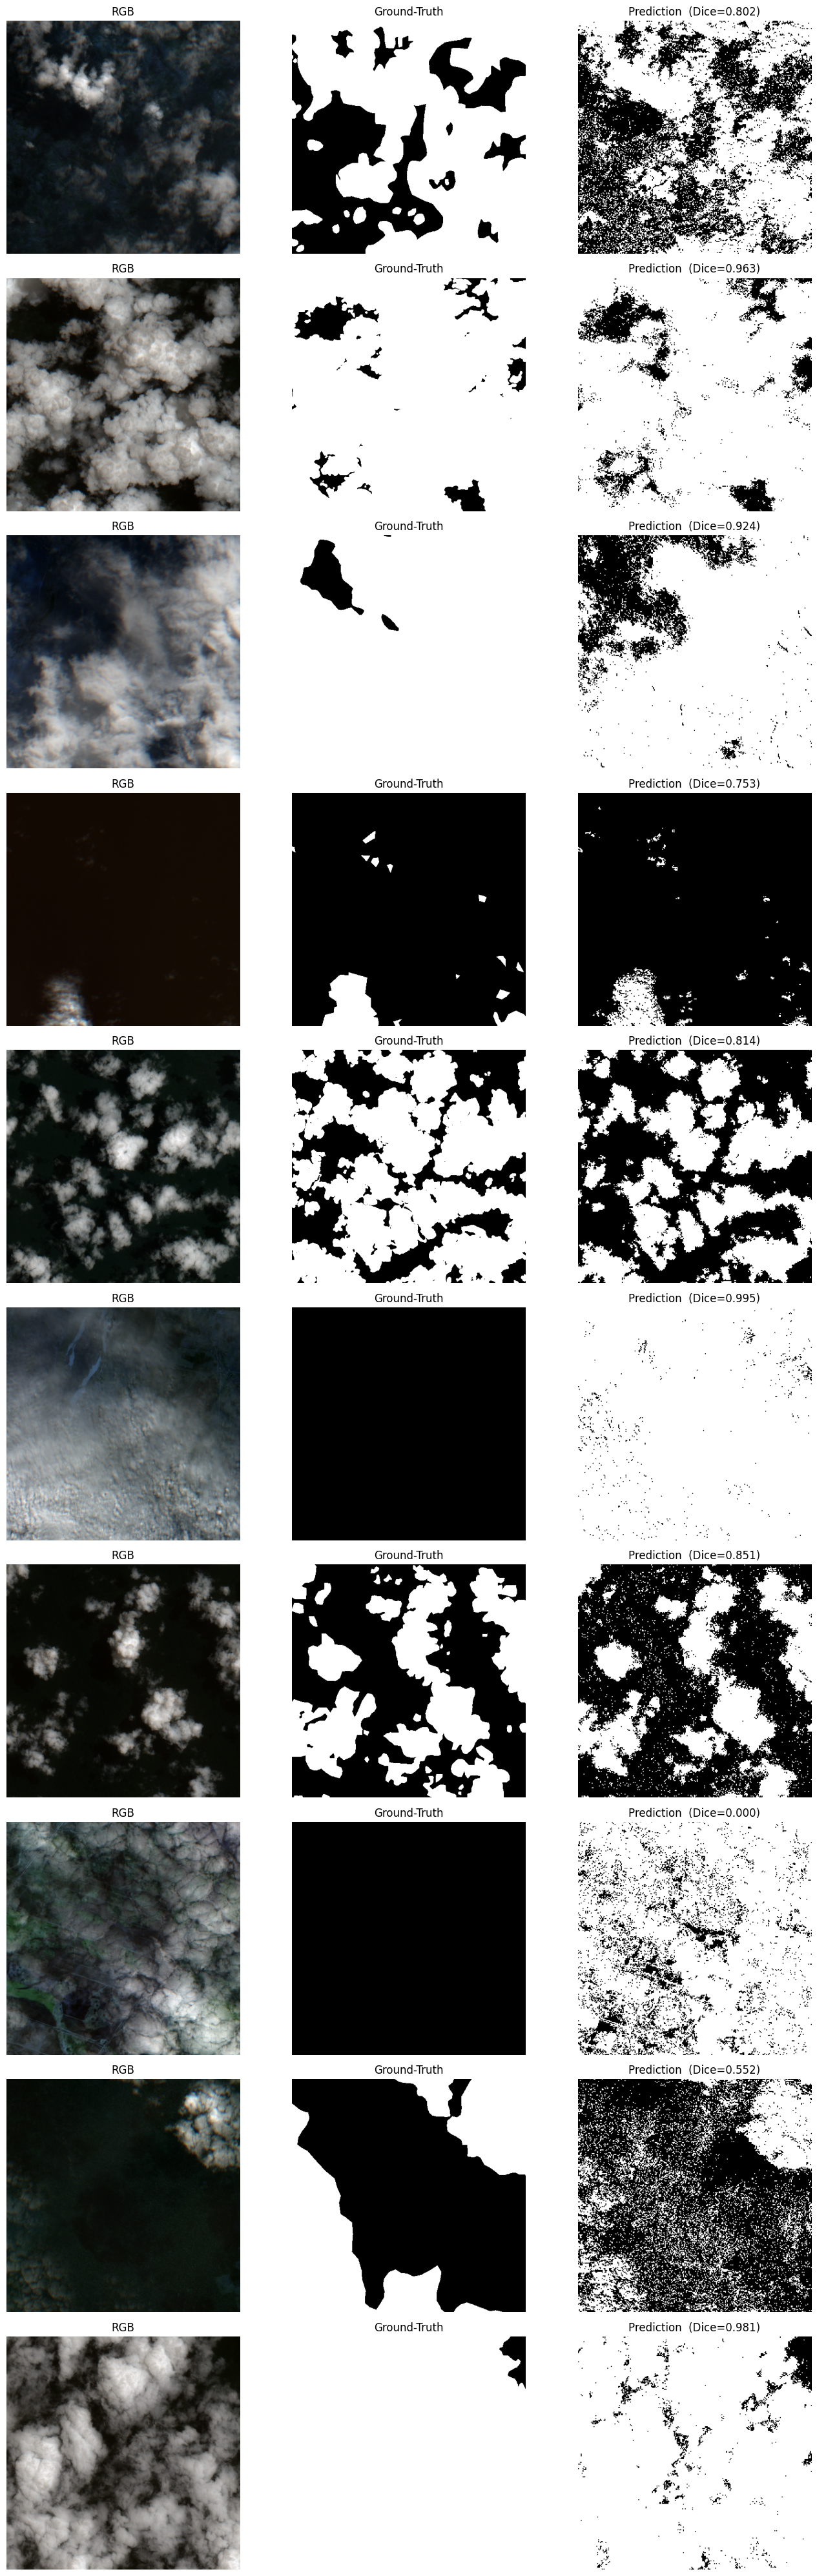

In [ ]:
# NOTE: Uncomment the following to visualize predictions

# SAMPLES = 10
# idxs = np.random.choice(len(val_img), SAMPLES, replace=False)
# fig, axes = plt.subplots(SAMPLES,3, figsize=(14,4*SAMPLES))
# for row,idx in enumerate(idxs):
#     img = read_image(val_img[idx])
#     gt  = read_mask(val_msk[idx])
#     prd = predict_mask(img, rf_clf, resize_to=CONFIG['resize_for_rf'])
    
#     rgb = (img[...,:3]-img[...,:3].min())/(img[...,:3].ptp()+1e-6)
#     axes[row,0].imshow(rgb); axes[row,0].set_axis_off(); axes[row,0].set_title('RGB')
#     axes[row,1].imshow(gt, cmap='gray'); axes[row,1].set_axis_off(); axes[row,1].set_title('Ground-Truth')
#     axes[row,2].imshow(prd, cmap='gray'); axes[row,2].set_axis_off(); 
#     axes[row,2].set_title(f'Prediction  (Dice={dice_coef(prd,gt):.3f})')
# plt.tight_layout(); plt.show()

In [ ]:
# NOTE: Uncomment the following to profile inference

# sample_img = read_image(val_img[0])
# flat_tensor = torch.from_numpy(sample_img.reshape(-1,4))

# with profile(activities=[ProfilerActivity.CPU],
#              profile_memory=True, record_shapes=True) as prof:
#     with record_function("rf_inference"):
#         _ = rf_clf.predict(flat_tensor.numpy())

# with open(LOGS_PATH,'w') as f: f.write(str(prof.key_averages().table(sort_by="cpu_time_total")))
# print(f'Profiler report saved at:  {LOGS_PATH}')

Profiler report saved at:  /kaggle/working/rf_profiler.txt


Dice:: min:0.000 | median:0.864 | mean:0.743 | max:1.000


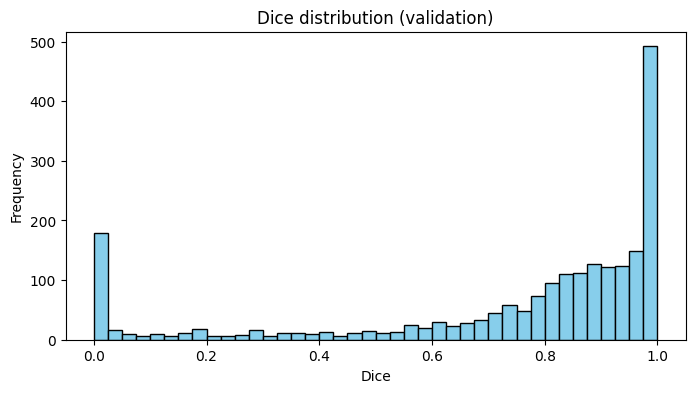

In [ ]:
# NOTE: Uncomment the following to visualize Dice distribution 

# d_arr = np.array(dice_scores)
# print(f'Dice:: min:{d_arr.min():.3f} | median:{np.median(d_arr):.3f} | mean:{d_arr.mean():.3f} | max:{d_arr.max():.3f}')

# plt.figure(figsize=(8,4))
# plt.hist(d_arr, bins=40, color='skyblue', edgecolor='black')
# plt.xlabel('Dice'); plt.ylabel('Frequency'); plt.title('Dice distribution (validation)')
# plt.show()

In [ ]:
def rle_encode(mask):
    """
    Encodes a binary mask using Run-Length Encoding (RLE).
    
    Args:
        mask (np.ndarray): 2D binary mask (0s and 1s).

    Returns:
        str: RLE-encoded string, or a single space " " if mask is all zeros.
    """
    if np.sum(mask) == 0:
        return " "
    
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    runs[::2] -= 1

    return " ".join(map(str, runs))

def rle_decode(mask_rle: str, shape=(256, 256)) -> np.ndarray:
    """
    Decodes an RLE-encoded string into a binary mask with validation checks.

    Args:
        mask_rle (str): RLE string to decode.
        shape (tuple, optional): Shape (height, width) of the output mask. Defaults to (256, 256).

    Returns:
        np.ndarray: Decoded 2D binary mask.
    """
    if not isinstance(mask_rle, str) or not mask_rle.strip() or mask_rle.lower() == 'nan':
        return np.zeros(shape, dtype=np.uint8)
    
    try:
        s = list(map(int, mask_rle.split()))
    except:
        raise Exception("RLE segmentation must be a string and containing only integers")
    
    if len(s) % 2 != 0:
        raise Exception("RLE segmentation must have even-length (start, length) pairs")
    
    if any(x < 0 for x in s):
        raise Exception("RLE segmentation must not contain negative values")
    
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    starts, lengths = s[0::2], s[1::2]
    
    for start, length in zip(starts, lengths):
        if start >= mask.size or start + length > mask.size:
            raise Exception("RLE indices exceed image size")
        mask[start:start + length] = 1
    
    return mask.reshape(shape, order='F')

In [ ]:
def run_inference_to_csv(tiff_dir, model, csv_path, img_size, 
                         rle_size, device, threshold, show, max_show) -> None:
    """
    Runs inference on TIFF images, saves segmentation masks as RLE in a CSV file,
    and optionally visualizes predictions.

    Args:
        tiff_dir (str or Path): Directory containing TIFF images.
        model: Trained model for inference.
        csv_path (str or Path): Destination path for the output CSV.
        img_size (int): Resized dimensions for inference.
        rle_size (int): Size for RLE mask encoding.
        device (torch.device): Device for model inference.
        threshold (float): Threshold for binarizing the model output.
        show (bool): Flag to display visualizations.
        max_show (int): Maximum number of visualizations to display.

    Returns:
        None
    """
    tiff_paths: List[Path] = sorted(Path(tiff_dir).glob("*.tif*"))
    assert tiff_paths, f"No TIFF images found in '{tiff_dir}'."

    rows, visuals = [], []

    for p in tqdm(tiff_paths, desc="Inference"):
        with rasterio.open(p) as src:
            img4 = np.stack([src.read(i + 1) for i in range(4)], axis=2).astype(np.float32)

        for c in range(4):
            m = img4[..., c].max()
            if m > 0:
                img4[..., c] /= m

        img_r = cv2.resize(img4, (img_size, img_size), cv2.INTER_LINEAR)
        mask_pred = predict_mask(img4, model, resize_to=CONFIG['resize_for_rf'])
        mask_rle = resize(mask_pred, (rle_size, rle_size), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)
        
        rows.append(
            {
                "id": p.stem,
                "segmentation": rle_encode(mask_rle),
            }
        )

        if show and len(visuals) < max_show:
            rgb_disp = img_r[..., :3]
            rgb_disp = (rgb_disp - rgb_disp.min()) / (rgb_disp.ptp() + 1e-6)
            visuals.append((rgb_disp, mask_pred))

    df = pd.DataFrame(rows)
    df["id"] = df["id"].astype(str)
    df.to_csv(csv_path, index=False)
    print(f"\nSaved {len(rows)} predictions → {csv_path}")

    if show and visuals:
        n_vis       = len(visuals)
        dpi         = plt.rcParams.get("figure.dpi", 100)
        row_height  = 3.0
        max_inches  = 65500 / dpi
        rows_per_fig_max = int(max_inches // row_height)
    
        for chunk_idx in range(0, n_vis, rows_per_fig_max):
            chunk = visuals[chunk_idx : chunk_idx + rows_per_fig_max]
            rows  = len(chunk)
            fig, axes = plt.subplots(rows, 3,
                                     figsize=(12, row_height * rows),
                                     squeeze=False)
    
            for r, (rgb, msk) in enumerate(chunk):
                axes[r, 0].imshow(rgb)
                axes[r, 0].set_title("Resized RGB")
                axes[r, 0].axis("off")
    
                axes[r, 1].imshow(rgb)
                axes[r, 1].imshow(msk, alpha=0.5, cmap="cool")
                axes[r, 1].set_title("Mask overlay")
                axes[r, 1].axis("off")
    
                axes[r, 2].imshow(msk, cmap="gray")
                axes[r, 2].set_title("Binary mask")
                axes[r, 2].axis("off")
    
            fig.tight_layout()
            plt.show()

In [ ]:
def load_model(path):
    """
    Loads a trained model from a specified file path using pickle.

    Args:
        path (str): Path to the file containing the pickled model.

    Returns:
        Model: The loaded model object.
    """
    with open(path, 'rb') as f:
        model = pickle.load(f)
    return model

Inference: 100%|██████████| 316/316 [02:42<00:00,  1.95it/s]



Saved 316 predictions → team_18.csv


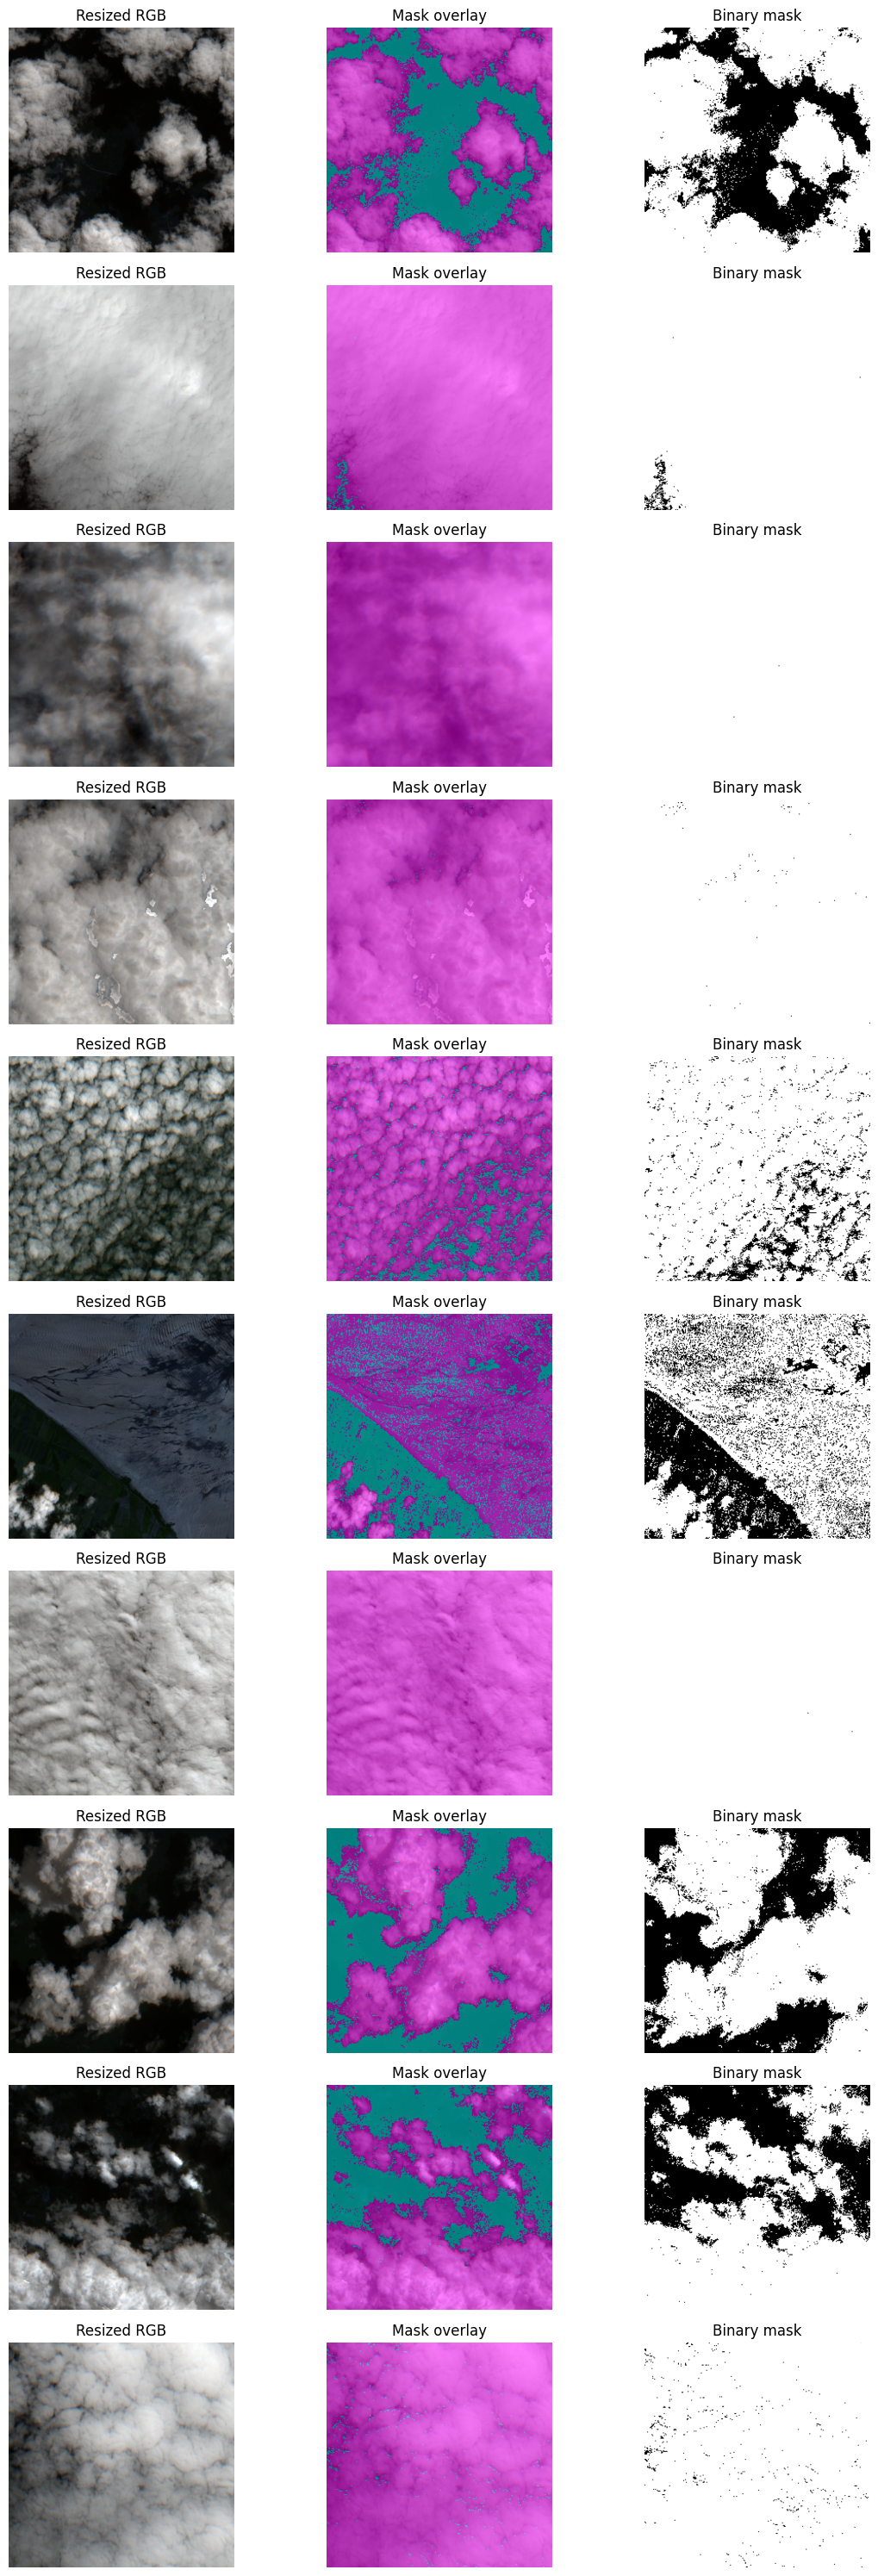

In [ ]:
TEST_SET = "/kaggle/input/cloud-masking-test-set-satellite-cmp25-course/test/test/data"
RF_CLF_MODEL_PATH = "/kaggle/input/cloud-mask-rf-clf/pytorch/default/1/cloud_mask_rf.pkl"

rf_clf = load_model(RF_CLF_MODEL_PATH)


run_inference_to_csv(
    tiff_dir=Path(TEST_SET),
    model=rf_clf,
    csv_path="team_18.csv",
    img_size=512,
    rle_size=256,
    device=CONFIG['device'],
    threshold=0.5,
    show=True,
    max_show=10,
)